In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("../data/raw/creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 284807
Columns: 31


In [20]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [22]:
missing_values = df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Series([], dtype: int64)


In [23]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [24]:
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [25]:
print("Class percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


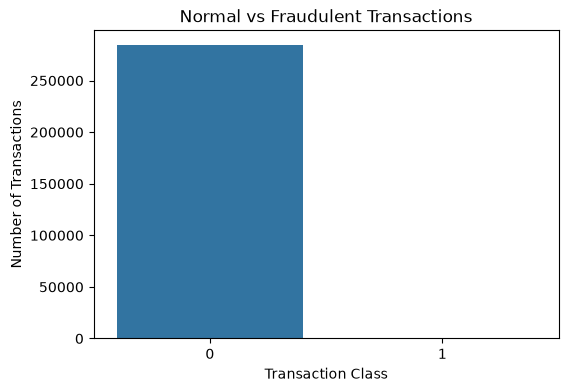

In [26]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [27]:
fraud_percentage = (df["Class"].sum() / len(df)) * 100

print(f"Fraud percentage: {fraud_percentage:.4f}%")

Fraud percentage: 0.1727%


In [28]:
print(df["Amount"].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


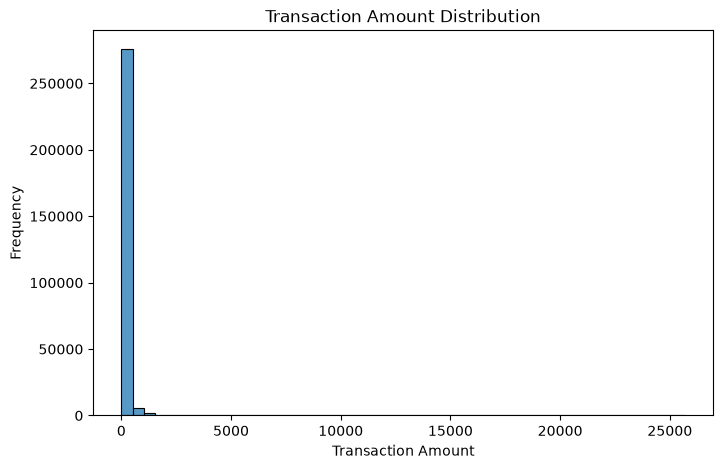

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

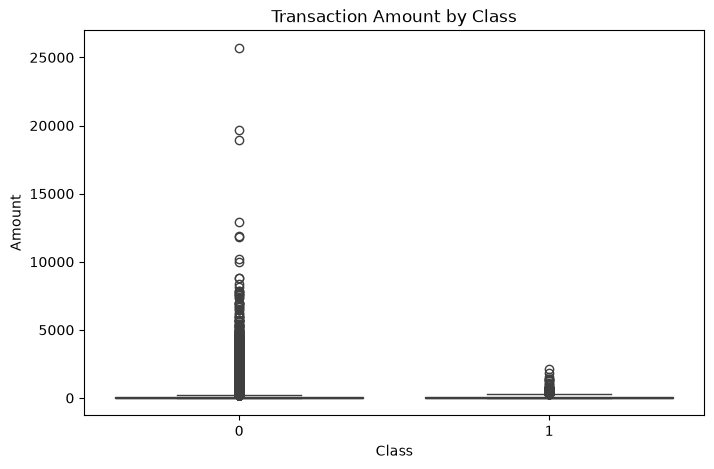

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

In [31]:
correlations = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)

print(correlations)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [32]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (227845, 30)
Testing features: (56962, 30)
Training target: (227845,)
Testing target: (56962,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Amount scaling completed!")

Amount scaling completed!


In [35]:
print("Training Amount mean:", X_train["Amount"].mean())
print("Training Amount std:", X_train["Amount"].std())

Training Amount mean: 3.742242677750753e-17
Training Amount std: 1.0000021944815372


In [38]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [39]:
print("Training percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting percentages:")
print(y_test.value_counts(normalize=True) * 100)

Training percentages:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Testing percentages:
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


In [40]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


c:\Users\Kishore\OneDrive\Desktop\bank-fraud-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
y_pred = baseline_model.predict(X_test)

y_probability = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [42]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_probability))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.66      0.73        98

    accuracy                           1.00     56962
   macro avg       0.91      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56850    14]
 [   33    65]]

ROC-AUC Score:
0.9482189154502544


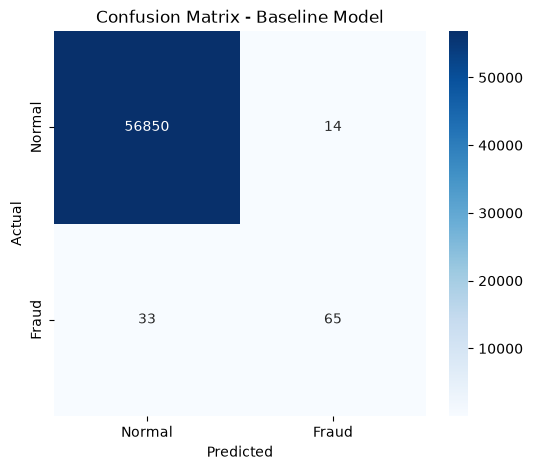

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_probability)

print("PR-AUC Score:", pr_auc)

PR-AUC Score: 0.7373369810472011


In [45]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

balanced_model.fit(X_train, y_train)

print("Class-weighted Logistic Regression trained successfully!")

Class-weighted Logistic Regression trained successfully!


c:\Users\Kishore\OneDrive\Desktop\bank-fraud-detection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
y_pred_balanced = balanced_model.predict(X_test)

y_probability_balanced = balanced_model.predict_proba(X_test)[:, 1]

print("Class-weighted predictions generated successfully!")

Class-weighted predictions generated successfully!


In [47]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_probability_balanced))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_probability_balanced))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Confusion Matrix:
[[55479  1385]
 [    8    90]]

ROC-AUC Score:
0.9725641487602357

PR-AUC Score:
0.7233328380432408


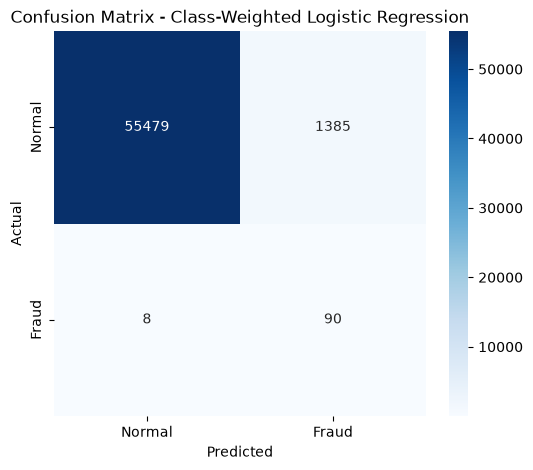

In [48]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix - Class-Weighted Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [50]:
y_pred_rf = rf_model.predict(X_test)

y_probability_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [51]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_probability_rf))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_probability_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56856     8]
 [   21    77]]

ROC-AUC Score:
0.9573101557026863

PR-AUC Score:
0.862939836265611


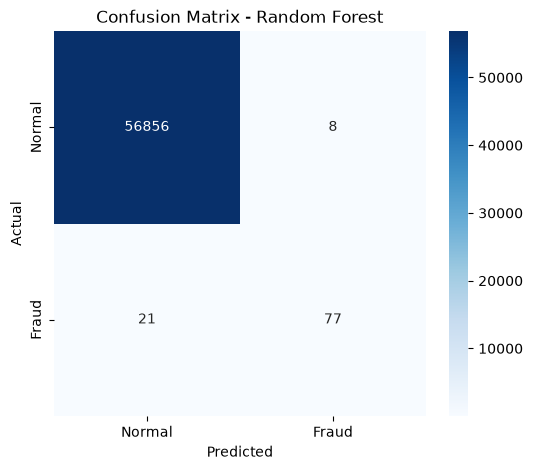

In [52]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

results = {
    "Logistic Regression": [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probability),
        average_precision_score(y_test, y_probability)
    ],
    
    "Balanced Logistic Regression": [
        precision_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_balanced),
        roc_auc_score(y_test, y_probability_balanced),
        average_precision_score(y_test, y_probability_balanced)
    ],
    
    "Random Forest": [
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_probability_rf),
        average_precision_score(y_test, y_probability_rf)
    ]
}

comparison_df = pd.DataFrame(
    results,
    index=["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"]
).T

print(comparison_df)

                              Precision    Recall  F1-Score   ROC-AUC  \
Logistic Regression            0.822785  0.663265  0.734463  0.948219   
Balanced Logistic Regression   0.061017  0.918367  0.114431  0.972564   
Random Forest                  0.905882  0.785714  0.841530  0.957310   

                                PR-AUC  
Logistic Regression           0.737337  
Balanced Logistic Regression  0.723333  
Random Forest                 0.862940  


In [54]:
import joblib

joblib.dump(rf_model, "../models/fraud_detection_model.pkl")
joblib.dump(scaler, "../models/amount_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [56]:
import joblib

joblib.dump(balanced_model, "../models/fraud_detection_model.pkl")
joblib.dump(scaler, "../models/amount_scaler.pkl")

print("Fast model saved successfully!")

Fast model saved successfully!
